# Interactive Sales Dashboard
Seaborn for the statistical charts (box/violin/heatmap), Plotly for the interactive pieces (hover tooltips, dropdown filter). Data is `sales_data.csv`. See `visualizations/` for every chart this notebook produces, and `interactive_dashboard.html` for the combined interactive version.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Day 1 - Seaborn Basics
Set a consistent theme/palette, load the data, first plot.

In [2]:
sns.set_theme(style="whitegrid", palette="deep")
PALETTE = ["#2563eb", "#16a34a", "#d97706", "#dc2626", "#7c3aed"]
sns.set_palette(PALETTE)

df = pd.read_csv("sales_data.csv")
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month_name()
df["MonthNum"] = df["Date"].dt.month
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Month,MonthNum
0,2024-01-01,Phone,7,37300,CUST001,East,261100,January,1
1,2024-01-02,Headphones,4,15406,CUST002,North,61624,January,1
2,2024-01-03,Phone,2,21746,CUST003,West,43492,January,1
3,2024-01-04,Headphones,1,30895,CUST004,East,30895,January,1
4,2024-01-05,Laptop,8,39835,CUST005,North,318680,January,1


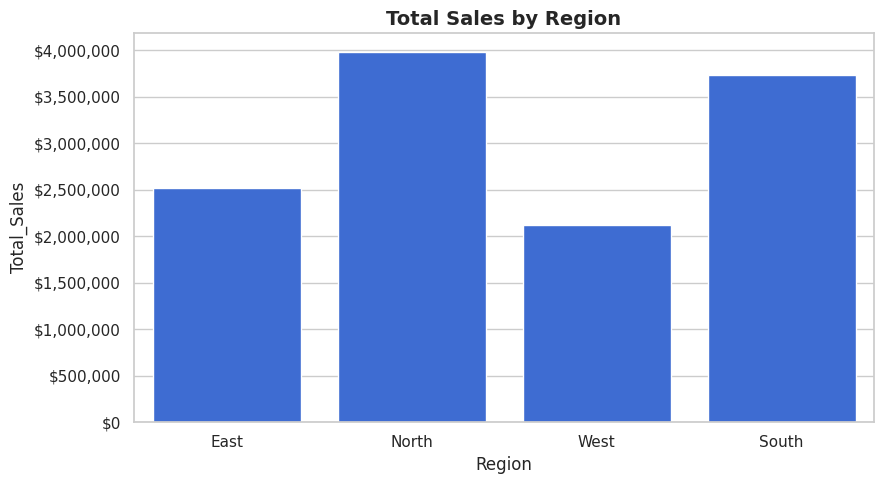

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=df, x="Region", y="Total_Sales", estimator=sum, errorbar=None, ax=ax)
ax.set_title("Total Sales by Region", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.savefig("visualizations/01_region_bar.png", dpi=150)
plt.show()

## Day 2 - Statistical Visualizations
Box plot for price spread by product, violin plot for order value spread by region.

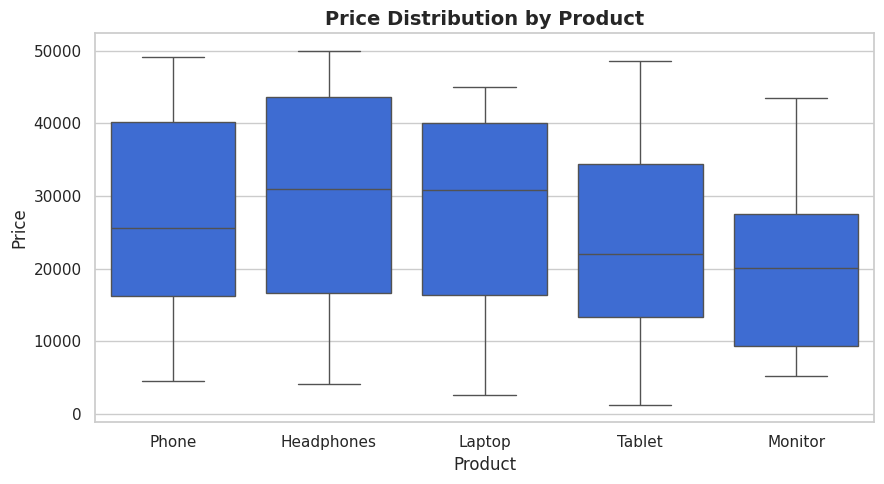

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="Product", y="Price", ax=ax)
ax.set_title("Price Distribution by Product", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/02_price_boxplot.png", dpi=150)
plt.show()

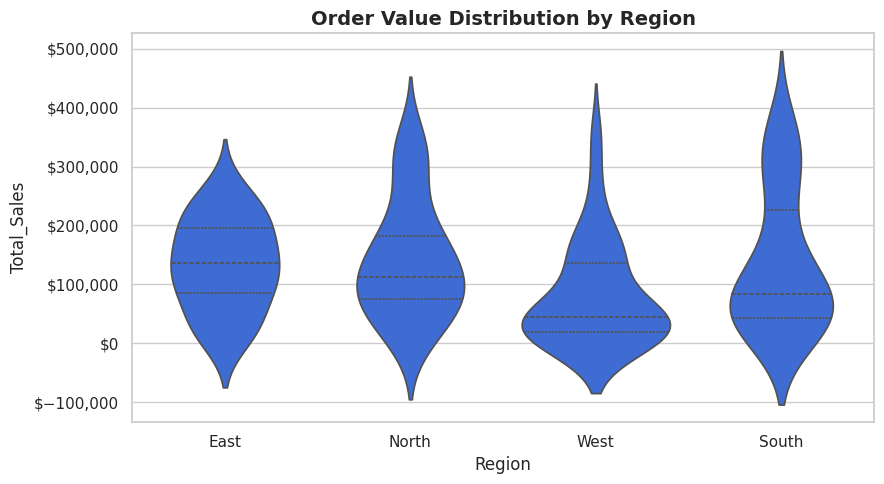

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=df, x="Region", y="Total_Sales", ax=ax, inner="quartile")
ax.set_title("Order Value Distribution by Region", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))
plt.tight_layout()
plt.savefig("visualizations/03_region_violin.png", dpi=150)
plt.show()

## Day 3 - Heatmaps & Correlation
Correlation matrix for the numeric columns, plus a region x product revenue heatmap (more actionable than raw correlation for this dataset).

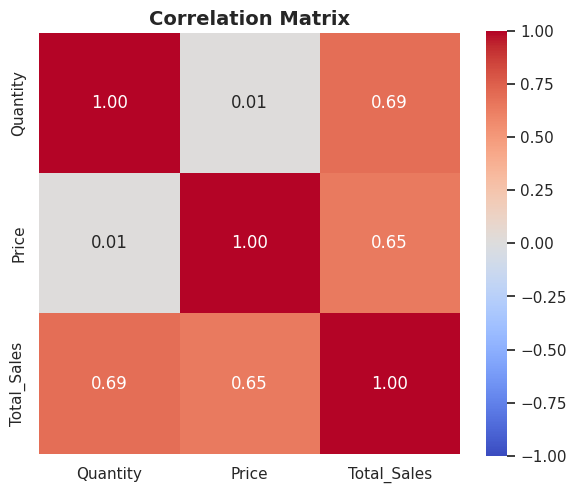

In [6]:
numeric_cols = ["Quantity", "Price", "Total_Sales"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/04_correlation_heatmap.png", dpi=150)
plt.show()

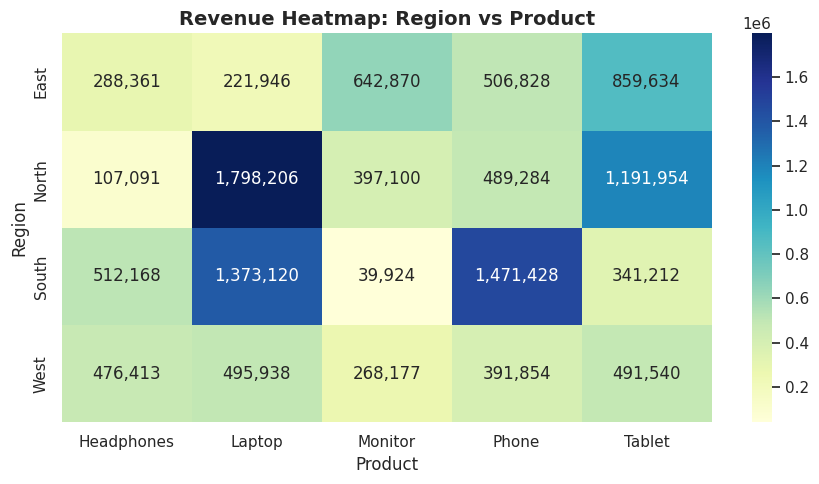

In [7]:
# region x product revenue as a heatmap too, more useful business-wise
pivot = df.pivot_table(values="Total_Sales", index="Region", columns="Product", aggfunc="sum", fill_value=0)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu", ax=ax)
ax.set_title("Revenue Heatmap: Region vs Product", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/05_region_product_heatmap.png", dpi=150)
plt.show()

## Day 4 - 2x2 Subplot Dashboard
Same color palette and title style as the individual charts, laid out as one static dashboard.

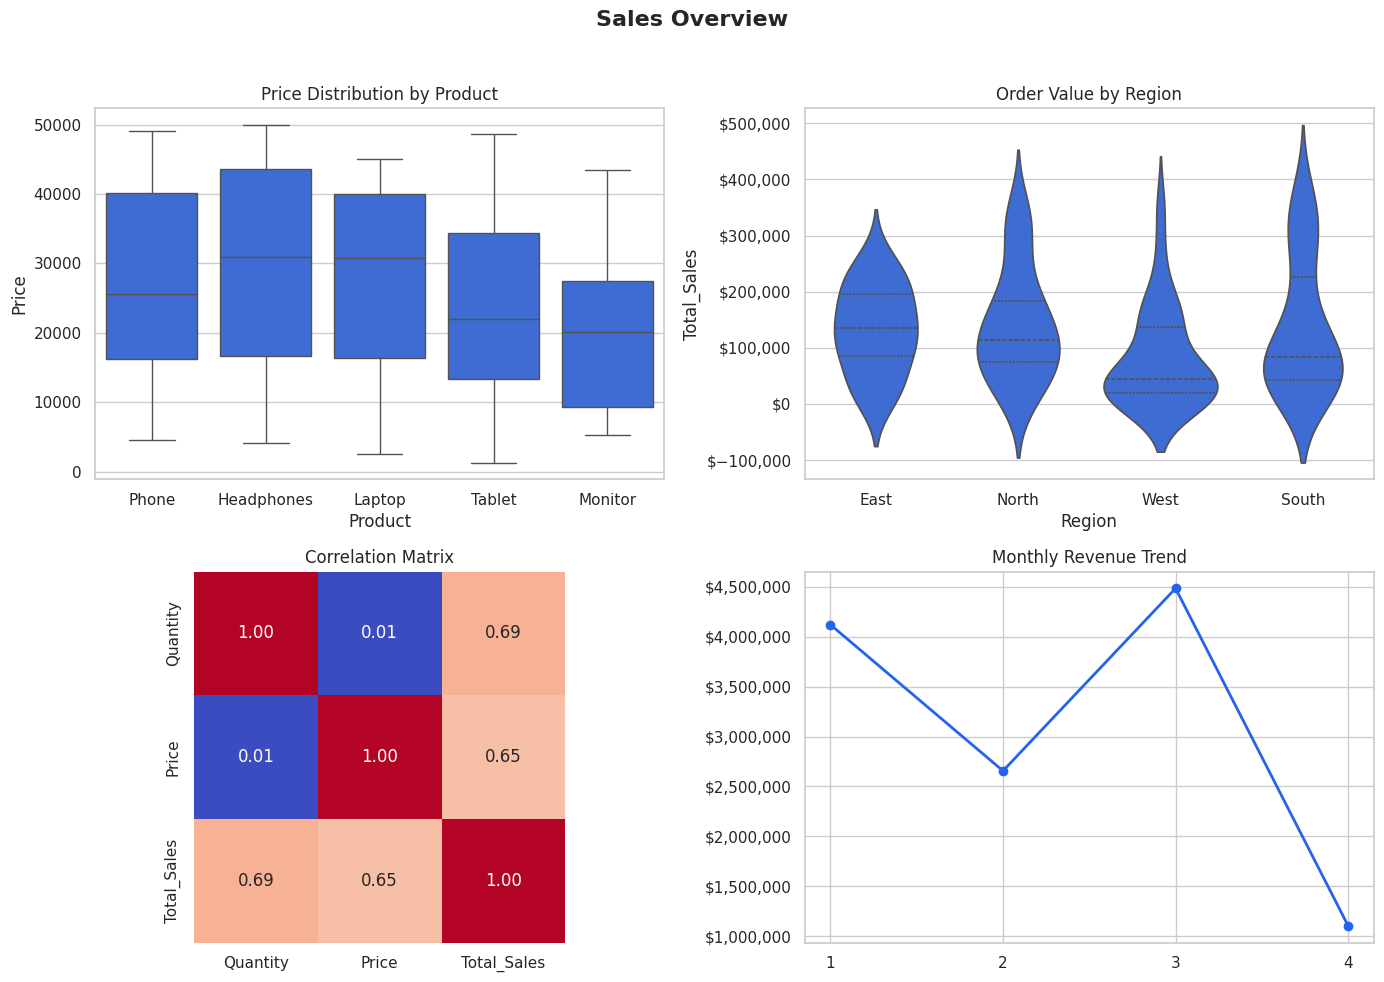

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Sales Overview", fontsize=16, fontweight="bold", y=0.98)

sns.boxplot(data=df, x="Product", y="Price", ax=axes[0, 0])
axes[0, 0].set_title("Price Distribution by Product")

sns.violinplot(data=df, x="Region", y="Total_Sales", ax=axes[0, 1], inner="quartile")
axes[0, 1].set_title("Order Value by Region")
axes[0, 1].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 0], square=True, cbar=False)
axes[1, 0].set_title("Correlation Matrix")

monthly = df.groupby("MonthNum")["Total_Sales"].sum()
axes[1, 1].plot(monthly.index, monthly.values, marker="o", linewidth=2, color=PALETTE[0])
axes[1, 1].set_title("Monthly Revenue Trend")
axes[1, 1].set_xticks(monthly.index)
axes[1, 1].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("visualizations/06_dashboard_2x2.png", dpi=150)
plt.show()

## Day 5 - Interactive Visualizations (Plotly)
Hover tooltips on the line chart, a dropdown filter on the bar chart, and a bubble scatter with hover detail.

In [9]:
fig_line = px.line(
    df.groupby(["MonthNum", "Month"], as_index=False)["Total_Sales"].sum(),
    x="Month", y="Total_Sales", markers=True,
    title="Monthly Revenue Trend",
    color_discrete_sequence=[PALETTE[0]],
)
fig_line.update_traces(hovertemplate="%{x}<br>Revenue: $%{y:,.0f}<extra></extra>")
fig_line.update_layout(template="plotly_white", yaxis_tickprefix="$")
fig_line.write_html("visualizations/interactive_monthly_trend.html")

In [10]:
# bar chart with a region dropdown filter
regions = ["All"] + sorted(df["Region"].unique().tolist())
fig_bar = go.Figure()
for region in regions:
    sub = df if region == "All" else df[df["Region"] == region]
    product_rev = sub.groupby("Product", as_index=False)["Total_Sales"].sum()
    fig_bar.add_trace(go.Bar(
        x=product_rev["Product"], y=product_rev["Total_Sales"],
        name=region, visible=(region == "All"),
        marker_color=PALETTE[0],
        hovertemplate="%{x}<br>Revenue: $%{y:,.0f}<extra></extra>",
    ))

buttons = []
for i, region in enumerate(regions):
    visible = [j == i for j in range(len(regions))]
    buttons.append(dict(label=region, method="update", args=[{"visible": visible}]))

fig_bar.update_layout(
    title="Product Revenue by Region (use dropdown to filter)",
    template="plotly_white",
    yaxis_tickprefix="$",
    updatemenus=[dict(active=0, buttons=buttons, x=1.15, y=1.15)],
)
fig_bar.write_html("visualizations/interactive_product_by_region.html")

In [11]:
# scatter with hover detail, quantity vs price sized by total sales
fig_scatter = px.scatter(
    df, x="Quantity", y="Price", size="Total_Sales", color="Product",
    hover_data=["Customer_ID", "Region", "Date"],
    title="Quantity vs Price (bubble size = order value)",
    color_discrete_sequence=PALETTE,
)
fig_scatter.update_layout(template="plotly_white")
fig_scatter.write_html("visualizations/interactive_quantity_price.html")

## Day 6 - Dashboard Integration
All the interactive charts combined into one Plotly dashboard (`interactive_dashboard.html`), plus a static preview image since this environment doesn't have headless Chrome for Plotly's image export.

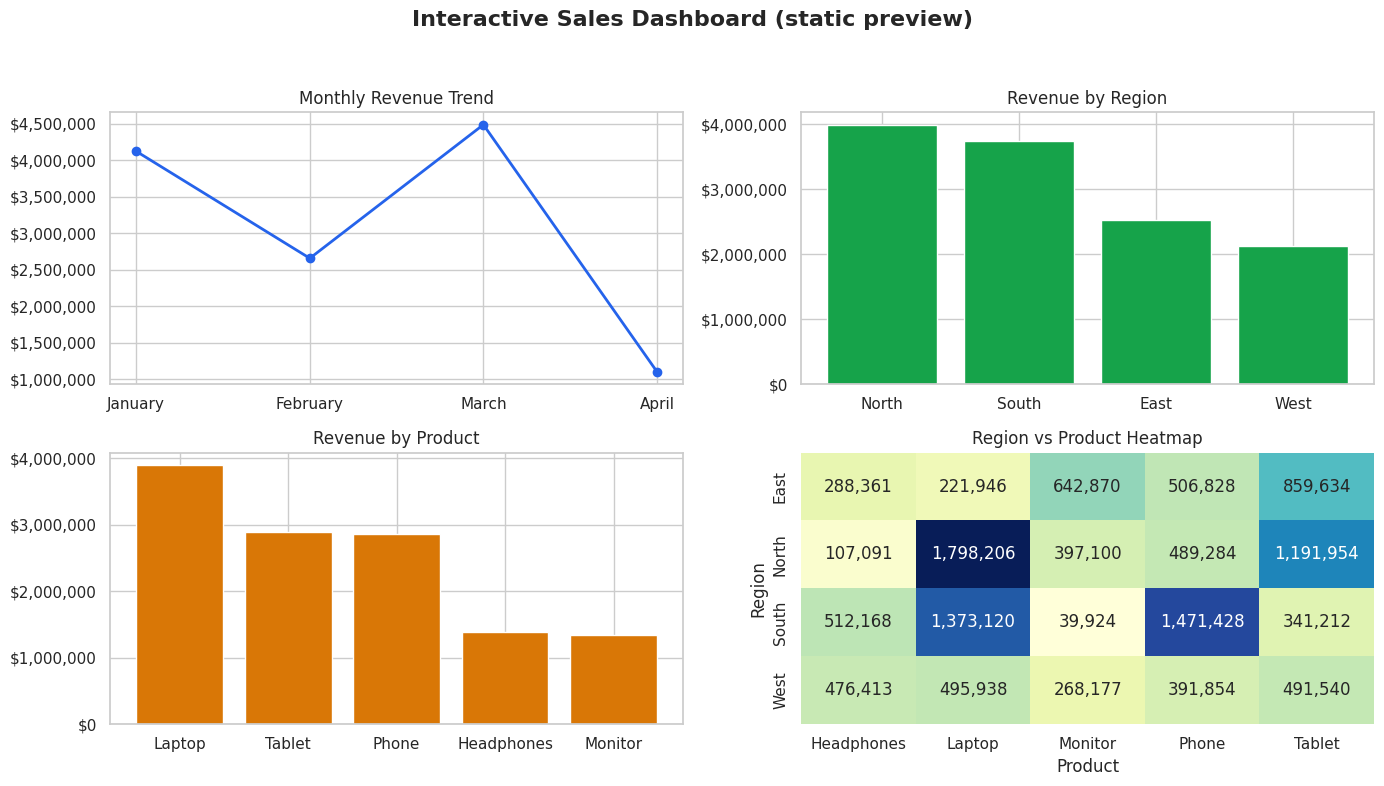

In [12]:
combined = make_subplots(
    rows=2, cols=2,
    subplot_titles=("Monthly Revenue Trend", "Revenue by Region", "Revenue by Product", "Region vs Product Heatmap"),
    specs=[[{"type": "scatter"}, {"type": "bar"}], [{"type": "bar"}, {"type": "heatmap"}]],
)

monthly_df = df.groupby(["MonthNum", "Month"], as_index=False)["Total_Sales"].sum()
combined.add_trace(
    go.Scatter(x=monthly_df["Month"], y=monthly_df["Total_Sales"], mode="lines+markers",
               line=dict(color=PALETTE[0], width=3), hovertemplate="%{x}<br>$%{y:,.0f}<extra></extra>"),
    row=1, col=1,
)

region_rev = df.groupby("Region", as_index=False)["Total_Sales"].sum().sort_values("Total_Sales", ascending=False)
combined.add_trace(
    go.Bar(x=region_rev["Region"], y=region_rev["Total_Sales"], marker_color=PALETTE[1],
           hovertemplate="%{x}<br>$%{y:,.0f}<extra></extra>"),
    row=1, col=2,
)

product_rev = df.groupby("Product", as_index=False)["Total_Sales"].sum().sort_values("Total_Sales", ascending=False)
combined.add_trace(
    go.Bar(x=product_rev["Product"], y=product_rev["Total_Sales"], marker_color=PALETTE[2],
           hovertemplate="%{x}<br>$%{y:,.0f}<extra></extra>"),
    row=2, col=1,
)

combined.add_trace(
    go.Heatmap(z=pivot.values, x=pivot.columns, y=pivot.index, colorscale="YlGnBu",
               hovertemplate="Region: %{y}<br>Product: %{x}<br>$%{z:,.0f}<extra></extra>"),
    row=2, col=2,
)

combined.update_layout(
    title_text="Interactive Sales Dashboard",
    template="plotly_white",
    showlegend=False,
    height=800,
)
combined.write_html("visualizations/interactive_dashboard.html")

# static preview of the same 2x2 layout (no headless chrome available for plotly export)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Interactive Sales Dashboard (static preview)", fontsize=16, fontweight="bold")

axes[0, 0].plot(monthly_df["Month"], monthly_df["Total_Sales"], marker="o", linewidth=2, color=PALETTE[0])
axes[0, 0].set_title("Monthly Revenue Trend")
axes[0, 0].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

axes[0, 1].bar(region_rev["Region"], region_rev["Total_Sales"], color=PALETTE[1])
axes[0, 1].set_title("Revenue by Region")
axes[0, 1].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

axes[1, 0].bar(product_rev["Product"], product_rev["Total_Sales"], color=PALETTE[2])
axes[1, 0].set_title("Revenue by Product")
axes[1, 0].yaxis.set_major_formatter(mticker.StrMethodFormatter("${x:,.0f}"))

sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="YlGnBu", ax=axes[1, 1], cbar=False)
axes[1, 1].set_title("Region vs Product Heatmap")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("visualizations/07_interactive_dashboard_preview.png", dpi=150)
plt.show()

## Day 7 - Headline Numbers
For the dashboard guide / write-up.

In [13]:
total_revenue = df["Total_Sales"].sum()
avg_order = df["Total_Sales"].mean()
top_region = region_rev.iloc[0]
top_product = product_rev.iloc[0]
print(f"Total Revenue: ${total_revenue:,.0f}")
print(f"Average Order Value: ${avg_order:,.0f}")
print(f"Top Region: {top_region['Region']} (${top_region['Total_Sales']:,.0f})")
print(f"Top Product: {top_product['Product']} (${top_product['Total_Sales']:,.0f})")

Total Revenue: $12,365,048
Average Order Value: $123,650
Top Region: North ($3,983,635)
Top Product: Laptop ($3,889,210)
